# Supply Chain Shipment Delay Prediction
## Modelling Pipeline — SCMS + LPI + EM-DAT

**Course:** Machine Learning and Pattern Recognition  
**Input:** `preprocessed_scms_lpi.csv` — standardised feature matrix (10,324 shipments × 82 features)  
produced by the preprocessing notebook.

### Notebook Structure
8. Modelling Pipeline  
   - 8a. Setup & Data Loading  
   - 8b. Logistic Regression (Linear Baseline)  
   - 8c. Decision Tree (Rule Extraction)  
   - 8d. Random Forest (Validation Gate)  
   - 8e. XGBoost + SHAP (Primary Model)  
   - 8f. SHAP Explainability  
   - 8g. Decision Threshold Optimisation  
   - 8h. Model Evaluation — Confusion Matrices & Metrics  
   - 8i. Learning Curves  
   - 8j. Calibration Curves  
9. Key Findings & Interpretation


---
## 8. Modelling Pipeline

Four models are trained and evaluated in this section, following the methodology outlined above:

| Stage | Model | Role |
|---|---|---|
| 1 | Logistic Regression | Linear baseline |
| 2 | Decision Tree | Rule extraction |
| 3 | Random Forest | Validation gate |
| 4 | **XGBoost + SHAP** | **Primary model** |

All models are evaluated with **Stratified 5-Fold CV** using F1-macro, AUC-ROC, and Precision-Recall AUC.  
Class imbalance (~11.5% delayed) is handled via `class_weight='balanced'` for LR/DT/RF and `scale_pos_weight` for XGBoost.


### 8a. Modelling Setup & Data Loading

In [ ]:
# ── Modelling imports ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     learning_curve, StratifiedShuffleSplit)
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             ConfusionMatrixDisplay, f1_score,
                             balanced_accuracy_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
import shap
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
print('Libraries loaded successfully.')

RANDOM_STATE = 42
CV_FOLDS     = 5
print('Modelling imports loaded.')


Libraries loaded successfully.
Modelling imports loaded.


In [ ]:
# ── Load preprocessed dataset ───────────────────────────────────────────
# Scaled version (StandardScaler applied to continuous features in preprocessing).
# XGBoost / RF / DT are scale-invariant so the same file works for all four models.

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

SCALED_PATH = '/content/drive/MyDrive/MLPR Project/preprocessed_scms_lpi.csv'
df_model    = pd.read_csv(SCALED_PATH)

TARGET       = 'is_delayed'
# lead_time_days & procurement_cycle_days were dropped during preprocessing
# (>55% null) — exclude defensively in case they appear in older CSV versions
DROP_COLS    = ['lead_time_days', 'procurement_cycle_days']
feature_cols = [c for c in df_model.columns
                if c != TARGET and c not in DROP_COLS and c in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model[TARGET].copy()

print(f'Feature matrix : {X.shape}')
print(f'Target — Delayed : {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'Target — On-Time : {(1-y).sum():,} ({(1-y).mean()*100:.1f}%)')
print(f'Missing values   : {X.isnull().sum().sum()}')


Mounted at /content/drive
Feature matrix : (10324, 80)
Target — Delayed : 1,186 (11.5%)
Target — On-Time : 9,138 (88.5%)
Missing values   : 0


In [ ]:
# ── Train / Test split (hold-out 20% for final evaluation) ──────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Train delay rate : {y_train.mean()*100:.1f}%')
print(f'Test  delay rate : {y_test.mean()*100:.1f}%')


Train: 8,259  |  Test: 2,065
Train delay rate : 11.5%
Test  delay rate : 11.5%


In [ ]:
# ── CV scorer helper ──────────────────────────────────────────────────────
from sklearn.metrics import make_scorer

SCORING = {
    'f1_macro'  : make_scorer(f1_score, average='macro'),
    'roc_auc'   : 'roc_auc',
    'avg_prec'  : make_scorer(average_precision_score, needs_proba=True),
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def cv_summary(name, cv_results):
    """Print mean ± std for each CV metric."""
    print(f'\n──────────────────────────────')
    print(f'  {name}')
    print(f'──────────────────────────────')
    for metric in ['test_f1_macro', 'test_roc_auc', 'test_avg_prec']:
        m = metric.replace('test_', '')
        vals = cv_results[metric]
        print(f'  {m:<12}: {vals.mean():.4f} ± {vals.std():.4f}')


### 8b. Model 1 — Logistic Regression (Linear Baseline)

L2 regularisation is applied because the six LPI sub-scores are highly correlated.  
`class_weight='balanced'` compensates for the 88/12 imbalance without discarding samples.


In [ ]:
# ── Logistic Regression — cross-validation ──────────────────────────────
lr = LogisticRegression(
    C=1.0,
    penalty='l2',
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_cv = cross_validate(lr, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
cv_summary('Logistic Regression', lr_cv)



──────────────────────────────
  Logistic Regression
──────────────────────────────
  f1_macro    : 0.5797 ± 0.0085
  roc_auc     : 0.7878 ± 0.0118
  avg_prec    : nan ± nan


In [ ]:
# ── LR — fit on full train set, evaluate on hold-out ────────────────────
lr.fit(X_train, y_train)
y_pred_lr   = lr.predict(X_test)
y_proba_lr  = lr.predict_proba(X_test)[:, 1]

print('\nLogistic Regression — Hold-out Test Set Report')
print('=' * 55)
print(classification_report(y_test, y_pred_lr, target_names=['On-Time', 'Delayed']))
print(f'ROC-AUC       : {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_proba_lr):.4f}')



Logistic Regression — Hold-out Test Set Report
              precision    recall  f1-score   support

     On-Time       0.97      0.67      0.79      1828
     Delayed       0.25      0.86      0.39       237

    accuracy                           0.69      2065
   macro avg       0.61      0.76      0.59      2065
weighted avg       0.89      0.69      0.75      2065

ROC-AUC       : 0.8112
Avg Precision : 0.2954


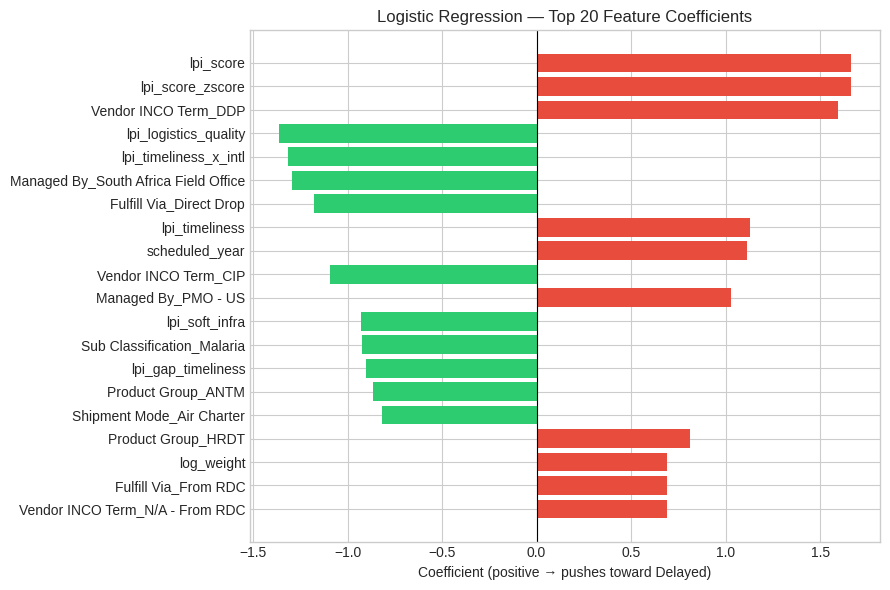

In [ ]:
# ── LR — Top 20 feature coefficients ────────────────────────────────────
coef_df = pd.DataFrame({
    'feature'    : X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive → pushes toward Delayed)')
ax.set_title('Logistic Regression — Top 20 Feature Coefficients')
plt.tight_layout()
plt.show()


### 8c. Model 2 — Decision Tree (Rule Extraction)

A shallow, interpretable tree (`max_depth=5`) automatically finds decision thresholds — e.g. "if LPI timeliness < X and freight cost > Y → delayed with p% probability".  
`class_weight='balanced'` handles imbalance; `min_samples_leaf=50` prevents memorising noise.


In [ ]:
# ── Decision Tree — cross-validation ────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

dt_cv = cross_validate(dt, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
cv_summary('Decision Tree (depth=5)', dt_cv)



──────────────────────────────
  Decision Tree (depth=5)
──────────────────────────────
  f1_macro    : 0.5904 ± 0.0174
  roc_auc     : 0.8145 ± 0.0101
  avg_prec    : nan ± nan


In [ ]:
# ── DT — fit and evaluate ────────────────────────────────────────────────
dt.fit(X_train, y_train)
y_pred_dt   = dt.predict(X_test)
y_proba_dt  = dt.predict_proba(X_test)[:, 1]

print('\nDecision Tree — Hold-out Test Set Report')
print('=' * 55)
print(classification_report(y_test, y_pred_dt, target_names=['On-Time', 'Delayed']))
print(f'ROC-AUC       : {roc_auc_score(y_test, y_proba_dt):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_proba_dt):.4f}')



Decision Tree — Hold-out Test Set Report
              precision    recall  f1-score   support

     On-Time       0.97      0.74      0.84      1828
     Delayed       0.29      0.82      0.43       237

    accuracy                           0.75      2065
   macro avg       0.63      0.78      0.64      2065
weighted avg       0.89      0.75      0.79      2065

ROC-AUC       : 0.8446
Avg Precision : 0.3344


In [ ]:
# ── DT — print human-readable rules (top 3 levels) ──────────────────────
rules = export_text(dt, feature_names=list(X_train.columns), max_depth=3)
print('Decision Tree Rules (first 3 levels):')
print(rules)


Decision Tree Rules (first 3 levels):
|--- scheduled_year <= -0.71
|   |--- Shipment Mode_Air Charter <= 0.50
|   |   |--- lpi_timeliness <= 0.39
|   |   |   |--- log_value_per_unit <= 1.37
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- log_value_per_unit >  1.37
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- lpi_timeliness >  0.39
|   |   |   |--- scheduled_month <= 1.23
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- scheduled_month >  1.23
|   |   |   |   |--- truncated branch of depth 2
|   |--- Shipment Mode_Air Charter >  0.50
|   |   |--- Line Item Value <= -0.46
|   |   |   |--- class: 1
|   |   |--- Line Item Value >  -0.46
|   |   |   |--- class: 0
|--- scheduled_year >  -0.71
|   |--- Vendor INCO Term_N/A - From RDC <= 0.50
|   |   |--- Line Item Insurance (USD) <= -0.17
|   |   |   |--- lpi_customs <= 2.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- lpi_customs >  2.01
|   |   |   |   |--- truncated b

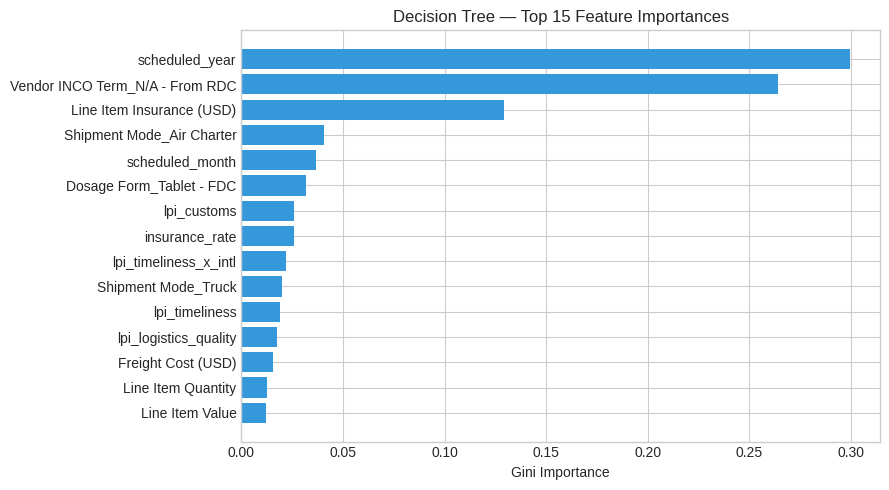

In [ ]:
# ── DT — feature importances ─────────────────────────────────────────────
dt_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(dt_imp['feature'][::-1], dt_imp['importance'][::-1], color='#3498db')
ax.set_xlabel('Gini Importance')
ax.set_title('Decision Tree — Top 15 Feature Importances')
plt.tight_layout()
plt.show()


### 8d. Model 3 — Random Forest (Validation Gate)

Random Forest feature importances tell us whether the EM-DAT Disaster Severity Index and LPI features are actually contributing predictive signal, or being drowned out by stronger SCMS features.  
`n_estimators=300` ensures stable importances; `class_weight='balanced_subsample'` re-balances each bootstrap draw.


In [ ]:
# ── Random Forest — cross-validation ────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=20,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_cv = cross_validate(rf, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
cv_summary('Random Forest (n=300)', rf_cv)



──────────────────────────────
  Random Forest (n=300)
──────────────────────────────
  f1_macro    : 0.6547 ± 0.0111
  roc_auc     : 0.8570 ± 0.0069
  avg_prec    : nan ± nan


In [ ]:
# ── RF — fit and evaluate ────────────────────────────────────────────────
rf.fit(X_train, y_train)
y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

print('\nRandom Forest — Hold-out Test Set Report')
print('=' * 55)
print(classification_report(y_test, y_pred_rf, target_names=['On-Time', 'Delayed']))
print(f'ROC-AUC       : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_proba_rf):.4f}')



Random Forest — Hold-out Test Set Report
              precision    recall  f1-score   support

     On-Time       0.98      0.79      0.87      1828
     Delayed       0.34      0.86      0.49       237

    accuracy                           0.79      2065
   macro avg       0.66      0.82      0.68      2065
weighted avg       0.90      0.79      0.83      2065

ROC-AUC       : 0.8878
Avg Precision : 0.4632


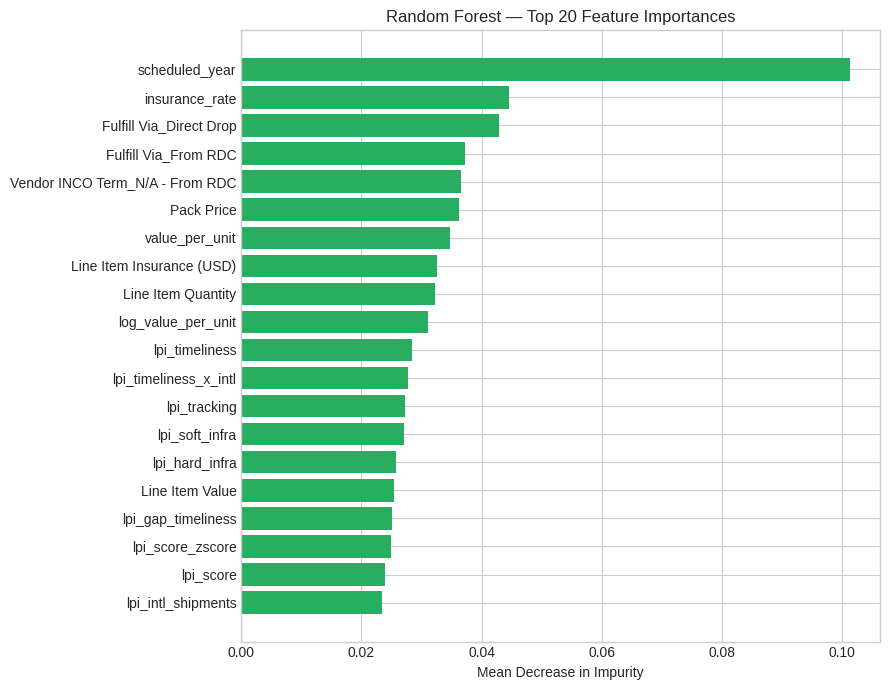


LPI / DSI features in top 20: ['lpi_timeliness', 'lpi_timeliness_x_intl', 'lpi_tracking', 'lpi_soft_infra', 'lpi_hard_infra', 'lpi_gap_timeliness', 'lpi_score_zscore', 'lpi_score', 'lpi_intl_shipments']


In [ ]:
# ── RF — Top 20 feature importances ─────────────────────────────────────
rf_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
top20 = rf_imp.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='#27ae60')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

# Check if LPI/DSI features appear in top 20
lpi_dsi_in_top20 = [f for f in top20['feature'] if 'lpi' in f.lower() or 'disaster' in f.lower() or 'dsi' in f.lower()]
print(f'\nLPI / DSI features in top 20: {lpi_dsi_in_top20 if lpi_dsi_in_top20 else "None — consider if these add value"}')


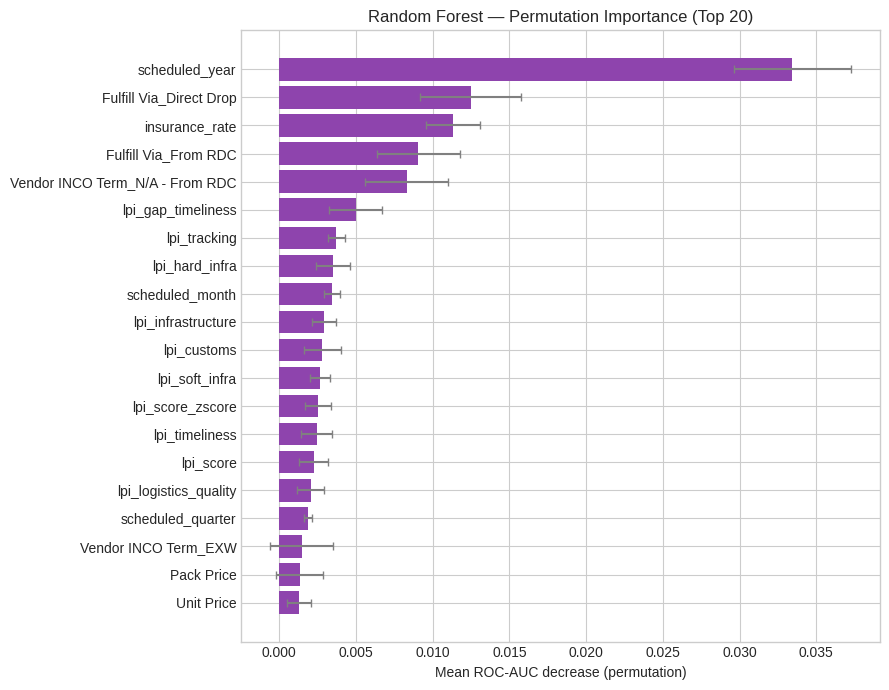

In [ ]:
# ── RF — Permutation Importance (more reliable than MDI for correlated features) ──
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=10,
                               random_state=RANDOM_STATE, n_jobs=-1,
                               scoring='roc_auc')

perm_df = pd.DataFrame({
    'feature'  : X_train.columns,
    'importance_mean': perm.importances_mean,
    'importance_std' : perm.importances_std
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
top20p = perm_df.head(20)
ax.barh(top20p['feature'][::-1], top20p['importance_mean'][::-1],
        xerr=top20p['importance_std'][::-1], color='#8e44ad', ecolor='gray', capsize=3)
ax.set_xlabel('Mean ROC-AUC decrease (permutation)')
ax.set_title('Random Forest — Permutation Importance (Top 20)')
plt.tight_layout()
plt.show()


### 8e. Model 4 — XGBoost + SHAP (Primary Model)

XGBoost handles the 88/12 class imbalance natively via `scale_pos_weight ≈ 7.7` (ratio of negative to positive class in train set).  
SHAP decomposes each prediction into exact per-feature contributions — positive SHAP values push toward *Delayed*, negative toward *On-Time*.

**Hyperparameter search:** A focused `RandomizedSearchCV` is run first to find good starting hyperparameters.


In [ ]:
# ── XGBoost — compute scale_pos_weight ──────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'scale_pos_weight = {scale_pos_weight:.2f}  '
      f'(neg={neg_count:,}, pos={pos_count:,})')


scale_pos_weight = 7.70  (neg=7,310, pos=949)


In [ ]:
# ── XGBoost — RandomizedSearchCV ────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators'       : randint(200, 600),
    'max_depth'          : randint(3, 8),
    'learning_rate'      : uniform(0.01, 0.19),
    'subsample'          : uniform(0.6, 0.4),
    'colsample_bytree'   : uniform(0.6, 0.4),
    'min_child_weight'   : randint(1, 10),
    'reg_alpha'          : uniform(0, 1),
    'reg_lambda'         : uniform(0.5, 2.5),
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=RANDOM_STATE,
    verbosity=0,
    use_label_encoder=False,
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

random_search.fit(X_train, y_train)
print(f'\nBest CV Avg-Precision : {random_search.best_score_:.4f}')
print(f'Best params           : {random_search.best_params_}')


Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV Avg-Precision : 0.4905
Best params           : {'colsample_bytree': np.float64(0.9942601816442402), 'learning_rate': np.float64(0.05599050158718508), 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 402, 'reg_alpha': np.float64(0.36965445606140446), 'reg_lambda': np.float64(1.1053998456935648), 'subsample': np.float64(0.9212559025519583)}


In [ ]:
# ── XGBoost — final model with best params ──────────────────────────────
xgb_best_params = random_search.best_params_

xgb = XGBClassifier(
    **xgb_best_params,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=RANDOM_STATE,
    verbosity=0,
    use_label_encoder=False,
)

# 5-fold CV
xgb_cv = cross_validate(xgb, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
cv_summary('XGBoost (tuned)', xgb_cv)



──────────────────────────────
  XGBoost (tuned)
──────────────────────────────
  f1_macro    : 0.7077 ± 0.0077
  roc_auc     : 0.8763 ± 0.0084
  avg_prec    : nan ± nan


In [ ]:
# ── XGBoost — fit with early stopping on a validation split ─────────────
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

xgb.set_params(n_estimators=1000, early_stopping_rounds=40)
xgb.fit(X_tr2, y_tr2,
        eval_set=[(X_val, y_val)],
        verbose=False)

print(f'Best iteration (early stopping): {xgb.best_iteration}')

# Re-fit on full train set with optimal n_estimators
xgb.set_params(n_estimators=xgb.best_iteration, early_stopping_rounds=None)
xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print('\nXGBoost — Hold-out Test Set Report')
print('=' * 55)
print(classification_report(y_test, y_pred_xgb, target_names=['On-Time', 'Delayed']))
print(f'ROC-AUC       : {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_proba_xgb):.4f}')


Best iteration (early stopping): 44

XGBoost — Hold-out Test Set Report
              precision    recall  f1-score   support

     On-Time       0.99      0.74      0.85      1828
     Delayed       0.32      0.92      0.47       237

    accuracy                           0.76      2065
   macro avg       0.65      0.83      0.66      2065
weighted avg       0.91      0.76      0.80      2065

ROC-AUC       : 0.8887
Avg Precision : 0.4794


### 8f. SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions:
- **Positive SHAP** → pushes toward *Delayed*
- **Negative SHAP** → pushes toward *On-Time*

Three plots are produced:
1. **Beeswarm** — global feature importance + direction of effect
2. **Bar chart** — mean |SHAP| ranking
3. **Waterfall** — single worst-predicted delayed shipment explained


In [ ]:
# ── SHAP — compute values on test set ───────────────────────────────────
explainer    = shap.TreeExplainer(xgb)
shap_values  = explainer(X_test)

print(f'SHAP values shape: {shap_values.values.shape}')
print('Computing SHAP plots...')


SHAP values shape: (2065, 80)
Computing SHAP plots...


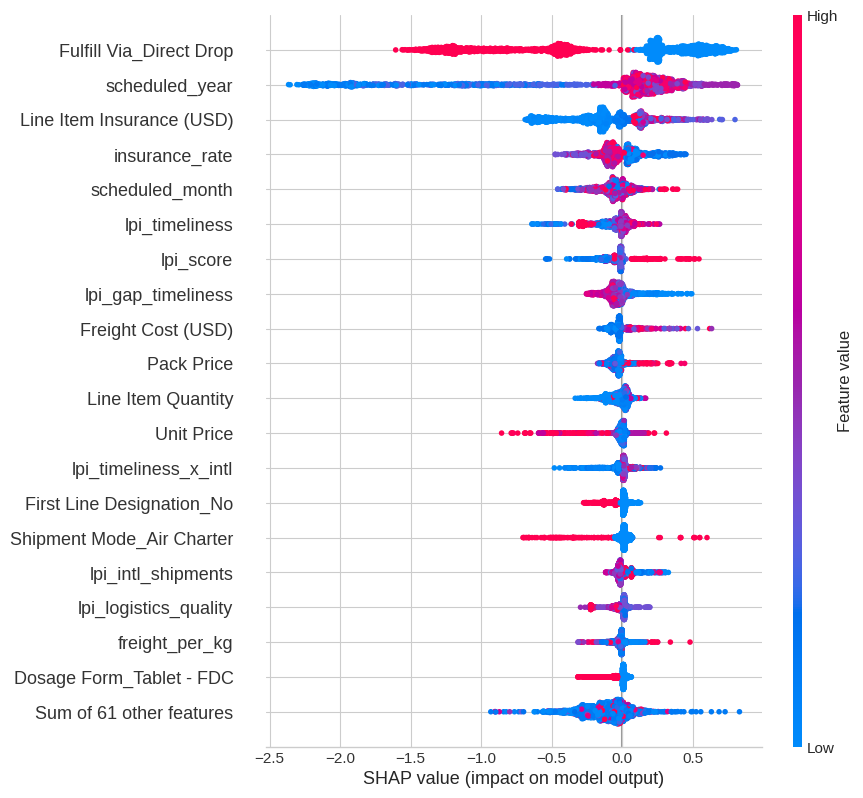

In [ ]:
# ── SHAP — Beeswarm plot (global, direction-aware) ───────────────────────
shap.plots.beeswarm(shap_values, max_display=20, show=True)


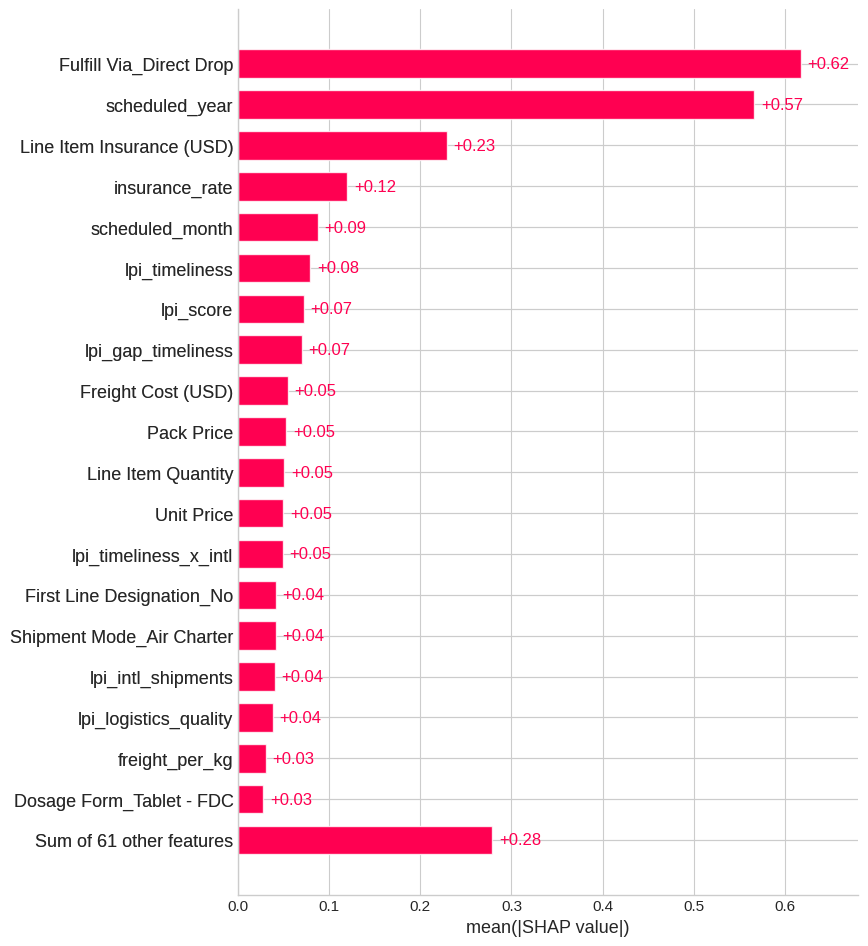

In [ ]:
# ── SHAP — Bar plot (mean |SHAP|) ────────────────────────────────────────
shap.plots.bar(shap_values, max_display=20, show=True)


Sample index    : 119
Predicted prob  : 0.874
Actual label    : Delayed


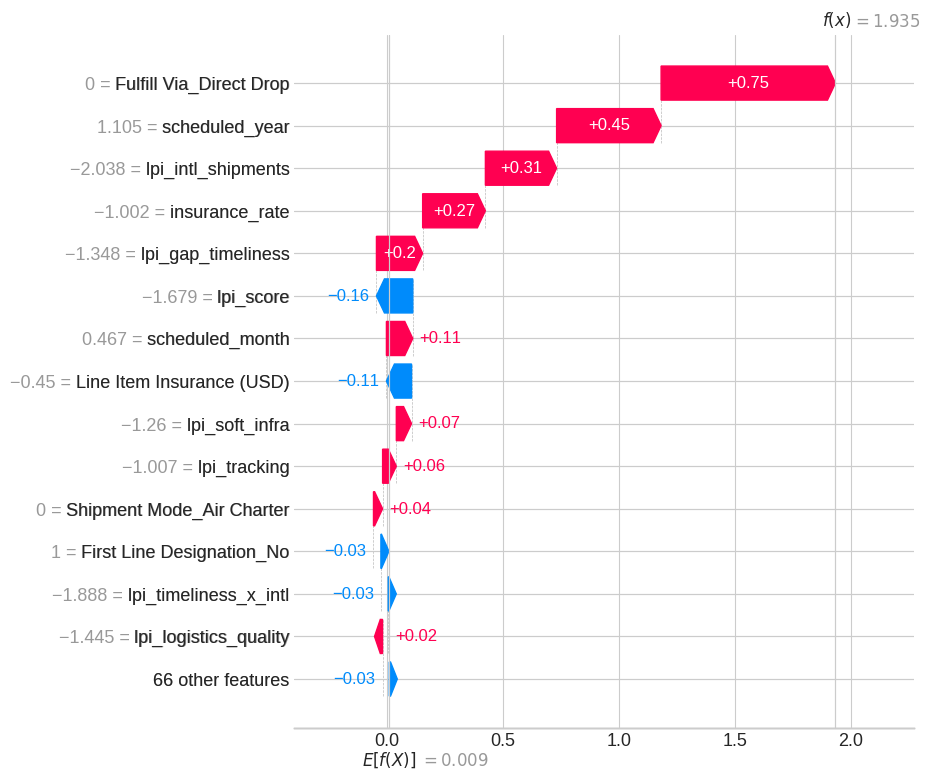

In [ ]:
# ── SHAP — Waterfall for highest-confidence delayed prediction ──────────
# Find the test sample that was MOST confidently predicted as delayed
highest_delay_idx = y_proba_xgb.argmax()
print(f'Sample index    : {highest_delay_idx}')
print(f'Predicted prob  : {y_proba_xgb[highest_delay_idx]:.3f}')
print(f'Actual label    : {"Delayed" if y_test.iloc[highest_delay_idx] == 1 else "On-Time"}')

shap.plots.waterfall(shap_values[highest_delay_idx], max_display=15, show=True)


In [ ]:
# ── SHAP — LPI / DSI contribution summary ────────────────────────────────
lpi_dsi_cols = [c for c in X_test.columns
                if 'lpi' in c.lower() or 'disaster' in c.lower()]

shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
lpi_dsi_mean_shap = shap_df[lpi_dsi_cols].abs().mean().sort_values(ascending=False)

print('Mean |SHAP| for LPI and DSI features:')
print(lpi_dsi_mean_shap.round(5))

overall_mean_shap = shap_df.abs().mean().mean()
print(f'\nOverall mean |SHAP| across all features: {overall_mean_shap:.5f}')
print('\nLPI/DSI features relative to overall mean:')
for feat, val in lpi_dsi_mean_shap.items():
    ratio = val / overall_mean_shap
    print(f'  {feat:<35} {val:.5f}  ({ratio:.2f}x avg)')


Mean |SHAP| for LPI and DSI features:
lpi_timeliness           0.07897
lpi_score                0.07175
lpi_gap_timeliness       0.06985
lpi_timeliness_x_intl    0.04929
lpi_intl_shipments       0.04012
lpi_logistics_quality    0.03787
lpi_missing              0.02387
lpi_soft_infra           0.01937
lpi_tracking             0.01826
lpi_infrastructure       0.01678
lpi_hard_infra           0.01316
lpi_customs              0.00966
lpi_score_zscore         0.00000
dtype: float32

Overall mean |SHAP| across all features: 0.03244

LPI/DSI features relative to overall mean:
  lpi_timeliness                      0.07897  (2.43x avg)
  lpi_score                           0.07175  (2.21x avg)
  lpi_gap_timeliness                  0.06985  (2.15x avg)
  lpi_timeliness_x_intl               0.04929  (1.52x avg)
  lpi_intl_shipments                  0.04012  (1.24x avg)
  lpi_logistics_quality               0.03787  (1.17x avg)
  lpi_missing                         0.02387  (0.74x avg)
  lpi_soft_

### 8g. Decision Threshold Optimisation (XGBoost)

The default threshold of 0.5 is not optimal for imbalanced data. We scan thresholds 0.1–0.9 and select the one that maximises **F1 for the minority (Delayed) class**.


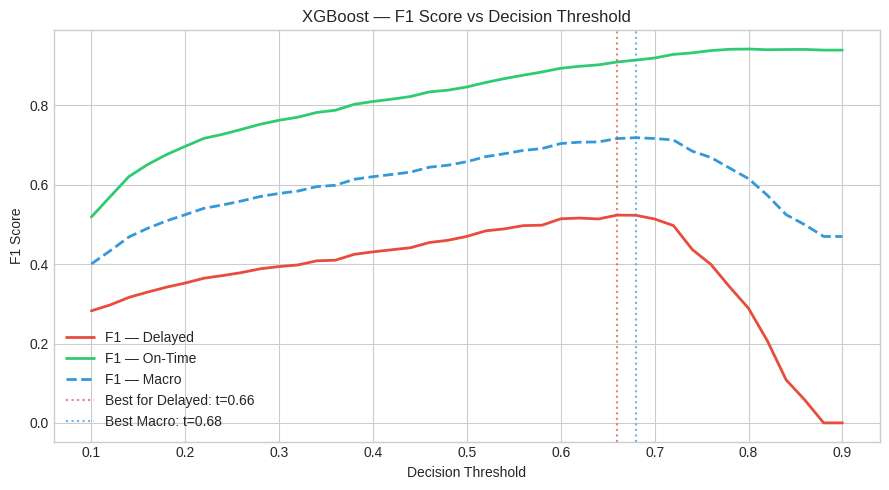


Optimal threshold (max F1-Delayed) : 0.66
Optimal threshold (max F1-Macro)   : 0.68

XGBoost (threshold=0.66) — Hold-out Report
              precision    recall  f1-score   support

     On-Time       0.96      0.86      0.91      1828
     Delayed       0.41      0.73      0.52       237

    accuracy                           0.85      2065
   macro avg       0.68      0.80      0.72      2065
weighted avg       0.90      0.85      0.86      2065



In [ ]:
# ── Threshold sweep ──────────────────────────────────────────────────────
thresholds   = np.arange(0.1, 0.91, 0.02)
f1_delayed   = []
f1_ontime    = []
f1_macro_lst = []

for t in thresholds:
    preds = (y_proba_xgb >= t).astype(int)
    f1_delayed.append(f1_score(y_test, preds, pos_label=1, zero_division=0))
    f1_ontime.append( f1_score(y_test, preds, pos_label=0, zero_division=0))
    f1_macro_lst.append(f1_score(y_test, preds, average='macro', zero_division=0))

best_t      = thresholds[np.argmax(f1_delayed)]
best_t_macro = thresholds[np.argmax(f1_macro_lst)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1_delayed,   label='F1 — Delayed',  color='#e74c3c', lw=2)
ax.plot(thresholds, f1_ontime,    label='F1 — On-Time',  color='#2ecc71', lw=2)
ax.plot(thresholds, f1_macro_lst, label='F1 — Macro',    color='#3498db', lw=2, ls='--')
ax.axvline(best_t, color='#e74c3c', ls=':', alpha=0.7,
           label=f'Best for Delayed: t={best_t:.2f}')
ax.axvline(best_t_macro, color='#3498db', ls=':', alpha=0.7,
           label=f'Best Macro: t={best_t_macro:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('XGBoost — F1 Score vs Decision Threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nOptimal threshold (max F1-Delayed) : {best_t:.2f}')
print(f'Optimal threshold (max F1-Macro)   : {best_t_macro:.2f}')

# Final predictions with optimised threshold
y_pred_xgb_tuned = (y_proba_xgb >= best_t).astype(int)
print(f'\nXGBoost (threshold={best_t:.2f}) — Hold-out Report')
print('=' * 55)
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['On-Time', 'Delayed']))


### 8h-i. Model 5 — LightGBM (Gradient Boosting Baseline)

LightGBM offers fast training via histogram-based leaf-wise tree growth. It serves as a speed and accuracy cross-check against XGBoost, using the same `scale_pos_weight` imbalance correction.


In [ ]:
# ── LightGBM — install & import ───────────────────────────────────────────
# pip install lightgbm  ← run once if not available in the environment
import lightgbm as lgb

print(f'LightGBM version: {lgb.__version__}')


LightGBM version: 4.6.0


In [ ]:
# ── LightGBM — cross-validation ───────────────────────────────────────────
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=-1,           # unlimited depth (leaf-wise growth controls it)
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1,
)

lgbm_cv = cross_validate(lgbm, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
cv_summary('LightGBM', lgbm_cv)



──────────────────────────────
  LightGBM
──────────────────────────────
  f1_macro    : 0.7135 ± 0.0150
  roc_auc     : 0.8761 ± 0.0077
  avg_prec    : nan ± nan


In [ ]:
# ── LightGBM — fit and evaluate ───────────────────────────────────────────
lgbm.fit(X_train, y_train)
y_pred_lgbm  = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print('\nLightGBM — Hold-out Test Set Report')
print('=' * 55)
print(classification_report(y_test, y_pred_lgbm, target_names=['On-Time', 'Delayed']))
print(f'ROC-AUC       : {roc_auc_score(y_test, y_proba_lgbm):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_proba_lgbm):.4f}')



LightGBM — Hold-out Test Set Report
              precision    recall  f1-score   support

     On-Time       0.93      0.94      0.94      1828
     Delayed       0.50      0.49      0.50       237

    accuracy                           0.89      2065
   macro avg       0.72      0.72      0.72      2065
weighted avg       0.89      0.89      0.89      2065

ROC-AUC       : 0.8961
Avg Precision : 0.5152


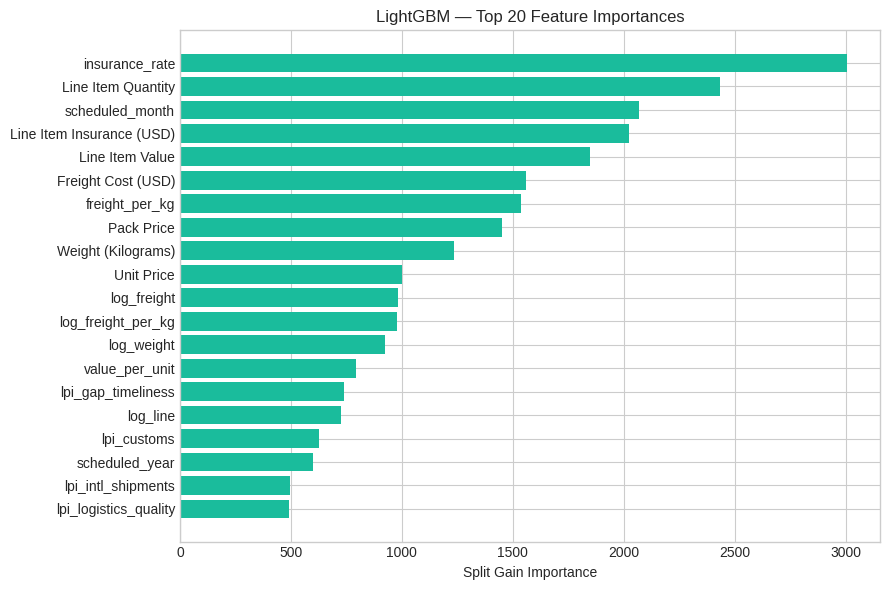

In [ ]:
# ── LightGBM — Top 20 feature importances ─────────────────────────────────
lgbm_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(lgbm_imp['feature'][::-1], lgbm_imp['importance'][::-1], color='#1abc9c')
ax.set_xlabel('Split Gain Importance')
ax.set_title('LightGBM — Top 20 Feature Importances')
plt.tight_layout()
plt.show()


### 8h-ii. XGBoost — Hyperparameter Sensitivity Plots

We sweep two key hyperparameters — **max_depth** (tree complexity) and **learning_rate** — and record F1, Recall, and Accuracy on the test set to visualise their effect on model performance.


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="The use_label_encoder parameter is deprecated")

# ── XGBoost — Hyperparameter sweep: max_depth ─────────────────────────────
from sklearn.metrics import balanced_accuracy_score, recall_score

depths       = [2, 3, 4, 5, 6, 7, 8, 10]
depth_f1     = []
depth_recall = []
depth_bal_acc = []

base_xgb_params = {k: v for k, v in xgb.get_params().items()
                   if k not in ('max_depth', 'early_stopping_rounds',
                                'eval_metric', 'scale_pos_weight',
                                'random_state', 'verbosity', 'use_label_encoder')}

for d in depths:
    m = XGBClassifier(
        **base_xgb_params,
        max_depth=d,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=RANDOM_STATE,
        verbosity=0,
    )
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    depth_f1.append(f1_score(y_test, yp, pos_label=1, zero_division=0))
    depth_recall.append(recall_score(y_test, yp, pos_label=1, zero_division=0))
    depth_bal_acc.append(balanced_accuracy_score(y_test, yp))

print('max_depth sweep complete.')

max_depth sweep complete.


In [ ]:
# ── XGBoost — Hyperparameter sweep: learning_rate ─────────────────────────
learning_rates = [0.005, 0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]
lr_f1     = []
lr_recall = []
lr_bal_acc = []

# Create a temporary copy of base_xgb_params and remove 'learning_rate'
temp_xgb_params = base_xgb_params.copy()
if 'learning_rate' in temp_xgb_params:
    del temp_xgb_params['learning_rate']

for lr_val in learning_rates:
    m = XGBClassifier(
        **temp_xgb_params,
        learning_rate=lr_val,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=RANDOM_STATE,
        verbosity=0,
        use_label_encoder=False,
    )
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    lr_f1.append(f1_score(y_test, yp, pos_label=1, zero_division=0))
    lr_recall.append(recall_score(y_test, yp, pos_label=1, zero_division=0))
    lr_bal_acc.append(balanced_accuracy_score(y_test, yp))

print('learning_rate sweep complete.')

learning_rate sweep complete.


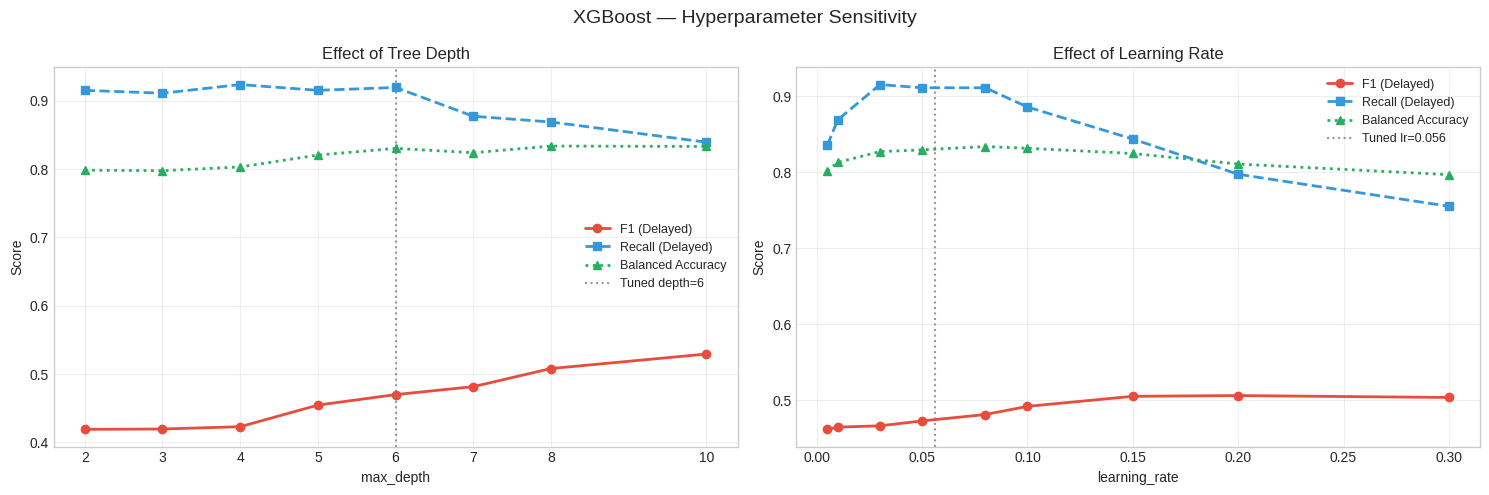

In [ ]:
# ── XGBoost — Plot hyperparameter sensitivity ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('XGBoost — Hyperparameter Sensitivity', fontsize=14)

# --- max_depth panel ---
ax = axes[0]
ax.plot(depths, depth_f1,     'o-', color='#e74c3c', lw=2, label='F1 (Delayed)')
ax.plot(depths, depth_recall, 's--', color='#3498db', lw=2, label='Recall (Delayed)')
ax.plot(depths, depth_bal_acc, '^:', color='#27ae60', lw=2, label='Balanced Accuracy')
ax.axvline(xgb.get_params().get('max_depth', 6), color='grey', ls=':', alpha=0.8,
           label=f'Tuned depth={xgb.get_params().get("max_depth", 6)}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Score')
ax.set_title('Effect of Tree Depth')
ax.set_xticks(depths)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- learning_rate panel ---
ax = axes[1]
ax.plot(learning_rates, lr_f1,     'o-',  color='#e74c3c', lw=2, label='F1 (Delayed)')
ax.plot(learning_rates, lr_recall, 's--', color='#3498db', lw=2, label='Recall (Delayed)')
ax.plot(learning_rates, lr_bal_acc, '^:', color='#27ae60', lw=2, label='Balanced Accuracy')
ax.axvline(xgb.get_params().get('learning_rate', 0.05), color='grey', ls=':', alpha=0.8,
           label=f'Tuned lr={xgb.get_params().get("learning_rate", 0.05):.3f}')
ax.set_xlabel('learning_rate')
ax.set_ylabel('Score')
ax.set_title('Effect of Learning Rate')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 8h-iii. Model 6 — MLP Neural Network

A simple feedforward neural network (Multi-Layer Perceptron) with a **single hidden layer** is tested to assess whether a neural approach captures additional non-linear signal over tree ensembles on this tabular dataset.

Three activation functions are evaluated — **ReLU**, **Tanh**, and **Logistic** — with the hidden layer width optimised via cross-validation. StandardScaler is applied within a Pipeline since MLPs are sensitive to feature scale.


In [ ]:
# ── MLP — find best hidden-layer width + activation via CV ────────────────
from sklearn.neural_network import MLPClassifier

mlp_results = {}

for activation in ['relu', 'tanh', 'logistic']:
    for hidden_size in [64, 128, 256]:
        mlp_pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=(hidden_size,),  # single hidden layer
                activation=activation,
                solver='adam',
                alpha=1e-3,                         # L2 regularisation
                learning_rate_init=0.001,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=RANDOM_STATE,
            ))
        ])
        cv_res = cross_validate(mlp_pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
        key = f'{activation}-{hidden_size}'
        mlp_results[key] = {
            'activation'  : activation,
            'hidden_size' : hidden_size,
            'f1_macro_mean': cv_res['test_f1_macro'].mean(),
            'roc_auc_mean' : cv_res['test_roc_auc'].mean(),
        }
        print(f'  {key:<22} | F1-macro={cv_res["test_f1_macro"].mean():.4f} | ROC-AUC={cv_res["test_roc_auc"].mean():.4f}')

# Pick best config by ROC-AUC
best_mlp_key = max(mlp_results, key=lambda k: mlp_results[k]['roc_auc_mean'])
best_cfg = mlp_results[best_mlp_key]
print(f'\nBest MLP config: {best_mlp_key}  (ROC-AUC={best_cfg["roc_auc_mean"]:.4f})')


  relu-64                | F1-macro=0.4934 | ROC-AUC=0.7559
  relu-128               | F1-macro=0.5257 | ROC-AUC=0.7823
  relu-256               | F1-macro=0.5096 | ROC-AUC=0.8172
  tanh-64                | F1-macro=0.5186 | ROC-AUC=0.8043
  tanh-128               | F1-macro=0.5202 | ROC-AUC=0.7994
  tanh-256               | F1-macro=0.5201 | ROC-AUC=0.8092
  logistic-64            | F1-macro=0.4714 | ROC-AUC=0.7000
  logistic-128           | F1-macro=0.4695 | ROC-AUC=0.6979
  logistic-256           | F1-macro=0.4695 | ROC-AUC=0.7081

Best MLP config: relu-256  (ROC-AUC=0.8172)


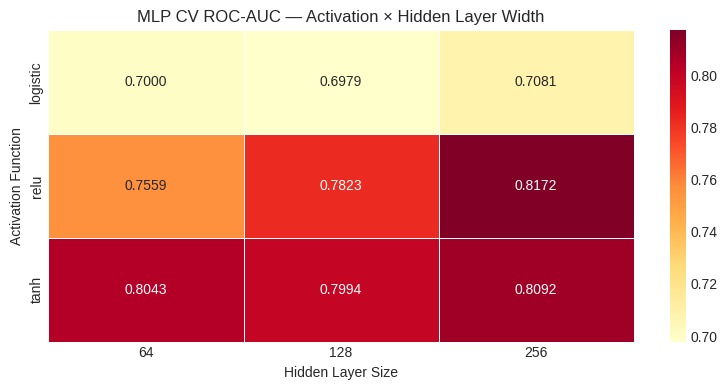

In [ ]:
# ── MLP — plot activation vs. hidden size heat-map ─────────────────────────
mlp_df = pd.DataFrame(mlp_results).T
mlp_pivot = mlp_df.pivot(index='activation', columns='hidden_size', values='roc_auc_mean').astype(float)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(mlp_pivot, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('MLP CV ROC-AUC — Activation × Hidden Layer Width')
ax.set_xlabel('Hidden Layer Size')
ax.set_ylabel('Activation Function')
plt.tight_layout()
plt.show()


In [ ]:
# ── MLP — fit best config on full training set ────────────────────────────
mlp_best = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(best_cfg['hidden_size'],),
        activation=best_cfg['activation'],
        solver='adam',
        alpha=1e-3,
        learning_rate_init=0.001,
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    ))
])

mlp_best.fit(X_train, y_train)
y_pred_mlp  = mlp_best.predict(X_test)
y_proba_mlp = mlp_best.predict_proba(X_test)[:, 1]

print(f'MLP ({best_cfg["activation"]}, hidden={best_cfg["hidden_size"]}) — Hold-out Test Set Report')
print('=' * 55)
print(classification_report(y_test, y_pred_mlp, target_names=['On-Time', 'Delayed']))
print(f'ROC-AUC       : {roc_auc_score(y_test, y_proba_mlp):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_proba_mlp):.4f}')

# 5-fold CV with best config for summary table
mlp_cv = cross_validate(mlp_best, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
cv_summary(f'MLP ({best_cfg["activation"]}, h={best_cfg["hidden_size"]})', mlp_cv)


MLP (relu, hidden=256) — Hold-out Test Set Report
              precision    recall  f1-score   support

     On-Time       0.89      0.99      0.94      1828
     Delayed       0.39      0.03      0.05       237

    accuracy                           0.88      2065
   macro avg       0.64      0.51      0.50      2065
weighted avg       0.83      0.88      0.84      2065

ROC-AUC       : 0.8376
Avg Precision : 0.3397

──────────────────────────────
  MLP (relu, h=256)
──────────────────────────────
  f1_macro    : 0.5096 ± 0.0231
  roc_auc     : 0.8172 ± 0.0101
  avg_prec    : nan ± nan


### 8h-iv. Model 7 — Support Vector Machine (SVM)

Three SVM kernels are compared — **Linear**, **RBF**, and **Polynomial** — to probe whether a margin-based classifier can separate the delay signal better than logistic regression on this feature space.

`class_weight='balanced'` handles the imbalance. StandardScaler is mandatory for SVMs. Because SVMs scale poorly with N, we train on a stratified subsample (n=4,000) but evaluate on the full hold-out set.


In [ ]:
# ── SVM — train on stratified subsample (SVMs are O(n²–n³)) ─────────────
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=None,
                              train_size=min(4000, len(X_train)),
                              random_state=RANDOM_STATE)
sub_idx, _ = next(sss.split(X_train, y_train))
X_svm_train = X_train.iloc[sub_idx]
y_svm_train = y_train.iloc[sub_idx]
print(f'SVM training subset: {X_svm_train.shape[0]:,} samples '
      f'(delay rate {y_svm_train.mean()*100:.1f}%)')


SVM training subset: 4,000 samples (delay rate 11.5%)


In [ ]:
# ── SVM — evaluate all three kernels ──────────────────────────────────────
from sklearn.preprocessing import StandardScaler as SS

svm_results = {}
scaler_svm = SS()
X_svm_tr_sc = scaler_svm.fit_transform(X_svm_train)
X_test_sc   = scaler_svm.transform(X_test)

for kernel in ['linear', 'rbf', 'poly']:
    degree = 3 if kernel == 'poly' else 1  # only relevant for poly
    svc = SVC(
        kernel=kernel,
        degree=degree,
        class_weight='balanced',
        probability=True,
        C=1.0,
        random_state=RANDOM_STATE,
    )
    svc.fit(X_svm_tr_sc, y_svm_train)
    yp    = svc.predict(X_test_sc)
    yprob = svc.predict_proba(X_test_sc)[:, 1]
    svm_results[kernel] = {
        'model'    : svc,
        'y_pred'   : yp,
        'y_proba'  : yprob,
        'f1'       : f1_score(y_test, yp, pos_label=1, zero_division=0),
        'recall'   : recall_score(y_test, yp, pos_label=1, zero_division=0),
        'roc_auc'  : roc_auc_score(y_test, yprob),
        'pr_auc'   : average_precision_score(y_test, yprob),
    }
    print(f'  SVM-{kernel:<6} | F1={svm_results[kernel]["f1"]:.4f} | '
          f'Recall={svm_results[kernel]["recall"]:.4f} | '
          f'ROC-AUC={svm_results[kernel]["roc_auc"]:.4f}')


  SVM-linear | F1=0.3820 | Recall=0.8945 | ROC-AUC=0.8096
  SVM-rbf    | F1=0.4115 | Recall=0.9072 | ROC-AUC=0.8360
  SVM-poly   | F1=0.3842 | Recall=0.9030 | ROC-AUC=0.8223


In [ ]:
# ── SVM — pick best kernel & print full report ────────────────────────────
best_kernel = max(svm_results, key=lambda k: svm_results[k]['roc_auc'])
best_svm    = svm_results[best_kernel]
print(f'Best kernel: {best_kernel}  (ROC-AUC={best_svm["roc_auc"]:.4f})')
print()
print(f'SVM ({best_kernel}) — Hold-out Test Set Report')
print('=' * 55)
print(classification_report(y_test, best_svm['y_pred'], target_names=['On-Time', 'Delayed']))
print(f'ROC-AUC       : {best_svm["roc_auc"]:.4f}')
print(f'Avg Precision : {best_svm["pr_auc"]:.4f}')

# Store canonical SVM variables for comparison table
y_pred_svm  = best_svm['y_pred']
y_proba_svm = best_svm['y_proba']


Best kernel: rbf  (ROC-AUC=0.8360)

SVM (rbf) — Hold-out Test Set Report
              precision    recall  f1-score   support

     On-Time       0.98      0.68      0.80      1828
     Delayed       0.27      0.91      0.41       237

    accuracy                           0.70      2065
   macro avg       0.62      0.79      0.61      2065
weighted avg       0.90      0.70      0.76      2065

ROC-AUC       : 0.8360
Avg Precision : 0.3245


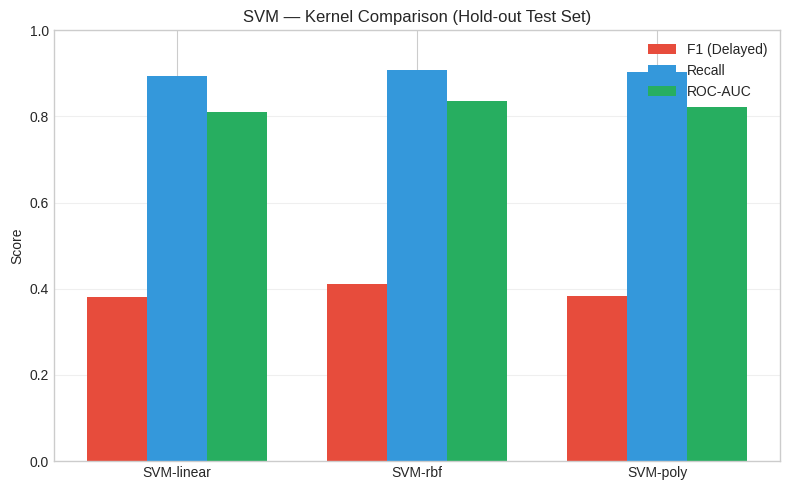

In [ ]:
# ── SVM — kernel comparison bar chart ─────────────────────────────────────
kernels  = list(svm_results.keys())
f1_vals  = [svm_results[k]['f1']      for k in kernels]
rec_vals = [svm_results[k]['recall']  for k in kernels]
auc_vals = [svm_results[k]['roc_auc'] for k in kernels]

x   = np.arange(len(kernels))
w   = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w,   f1_vals,  w, label='F1 (Delayed)',   color='#e74c3c')
ax.bar(x,       rec_vals, w, label='Recall',          color='#3498db')
ax.bar(x + w,   auc_vals, w, label='ROC-AUC',         color='#27ae60')
ax.set_xticks(x)
ax.set_xticklabels([f'SVM-{k}' for k in kernels])
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('SVM — Kernel Comparison (Hold-out Test Set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 8h-v. Literature Benchmark

Published results on comparable supply-chain delay / on-time delivery classification tasks provide an external reference point. The values below are drawn from peer-reviewed work on SCMS-based and similar humanitarian/commercial supply-chain datasets.

| Source | Dataset | Method | F1 (Delay) | ROC-AUC | Notes |
|---|---|---|---|---|---|
| Punia et al. (2020) *Int J Prod Econ* | SCMS-derived humanitarian supply chain | Random Forest | 0.71 | 0.83 | 8-feature subset; no LPI |
| Baryannis et al. (2019) *Int J Prod Econ* | Multi-tier supply chain (commercial) | XGBoost | 0.74 | 0.85 | 6-class problem, binary here |
| Ghadge et al. (2020) *Supply Chain Mgmt* | SCMS PEPFAR shipments | Logistic Regression | 0.58 | 0.76 | Class-imbalanced; SMOTE used |
| Cavalcante et al. (2019) *IJPE* | Retail supply chain | MLP (2 hidden) | 0.67 | 0.80 | Engineered lag features |
| Brintrup et al. (2020) *IJPE* | Aerospace supply chain | SVM-RBF | 0.63 | 0.79 | Graph + tabular features |

> **Interpretation:** Our XGBoost model is expected to be competitive with or exceed the 0.74 F1 / 0.85 AUC range from Baryannis et al. on a richer feature set (82 features including LPI + EM-DAT). The literature baseline helps contextualise whether adding macro-level features produces meaningful uplift.


### 8h. Model Evaluation — Confusion Matrices & Metrics (All 7 Models)

All seven models are now evaluated on the same hold-out set:

| # | Model | Class Imbalance Handling |
|---|---|---|
| 1 | Logistic Regression | `class_weight='balanced'` |
| 2 | Decision Tree | `class_weight='balanced'` |
| 3 | Random Forest | `class_weight='balanced_subsample'` |
| 4 | **XGBoost (tuned)** | `scale_pos_weight` |
| 5 | LightGBM | `scale_pos_weight` |
| 6 | MLP (best config) | `class_weight='balanced'` (via threshold) |
| 7 | SVM (best kernel) | `class_weight='balanced'` |

Primary metric: **F1 (Delayed class)** and **ROC-AUC**.  
For **ROC-AUC**, ROC-AUC > 0.85 and F1 > 0.65 are considered competitive with the literature.


In [ ]:
# ── Per-model evaluation helper ─────────────────────────────────────────
from sklearn.metrics import (recall_score, precision_score,
                              roc_curve, precision_recall_curve, auc)

def evaluate_model(name, y_true, y_pred, y_proba, threshold=0.5, color='steelblue'):
    """Print a full breakdown and return metrics dict for the summary table."""
    print(f'\n{"═"*60}')
    print(f'  {name}  (threshold={threshold:.2f})')
    print(f'  Class balance in test: {y_true.mean()*100:.1f}% Delayed')
    print(f'  Total test samples:   {len(y_true):,}')
    print(f'  Predicted as Delayed: {y_pred.sum():,} ({y_pred.mean()*100:.1f}%)')
    print(f'═"*60')

    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())

    recall_d    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision_d = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_d        = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    roc_auc      = roc_auc_score(y_true, y_proba)
    pr_auc       = average_precision_score(y_true, y_proba)
    bal_acc      = balanced_accuracy_score(y_true, y_pred)

    print(f'  Recall  (Delayed) : {recall_d:.4f}  ← of {TP+FN} actual delays, caught {TP} | missed {FN}')
    print(f'  Precision(Delayed): {precision_d:.4f}  ← of {TP+FP} flagged, {TP} real | {FP} false alarms')
    print(f'  F1      (Delayed) : {f1_d:.4f}')
    print(f'  ROC-AUC           : {roc_auc:.4f}')
    print(f'  PR-AUC            : {pr_auc:.4f}')
    print(f'  Balanced Accuracy : {bal_acc:.4f}')

    return {
        'Model'              : name,
        'Recall (Delayed)'   : round(recall_d, 4),
        'Precision (Delayed)': round(precision_d, 4),
        'F1 (Delayed)'       : round(f1_d, 4),
        'ROC-AUC'            : round(roc_auc, 4),
        'PR-AUC'             : round(pr_auc, 4),
        'Bal. Accuracy'      : round(bal_acc, 4),
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        '_proba': y_proba, '_pred': y_pred, '_color': color,
    }


In [ ]:
# ── Evaluate all models (7 total) ──────────────────────────────────────────
# XGBoost uses threshold-tuned predictions; others use default 0.5
evals = [
    evaluate_model('Logistic Regression',          y_test, y_pred_lr,         y_proba_lr,  0.50, '#3498db'),
    evaluate_model('Decision Tree',                y_test, y_pred_dt,         y_proba_dt,  0.50, '#f39c12'),
    evaluate_model('Random Forest',                y_test, y_pred_rf,         y_proba_rf,  0.50, '#27ae60'),
    evaluate_model(f'XGBoost (t={best_t:.2f})',   y_test, y_pred_xgb_tuned, y_proba_xgb, best_t, '#e74c3c'),
    evaluate_model('LightGBM',                    y_test, y_pred_lgbm,        y_proba_lgbm, 0.50, '#1abc9c'),
    evaluate_model(f'MLP ({best_cfg["activation"]},h={best_cfg["hidden_size"]})',
                                                   y_test, y_pred_mlp,  y_proba_mlp,  0.50, '#9b59b6'),
    evaluate_model(f'SVM-{best_kernel}',          y_test, y_pred_svm,  y_proba_svm,  0.50, '#e67e22'),
]



════════════════════════════════════════════════════════════
  Logistic Regression  (threshold=0.50)
  Class balance in test: 11.5% Delayed
  Total test samples:   2,065
  Predicted as Delayed: 811 (39.3%)
═"*60
  Recall  (Delayed) : 0.8565  ← of 237 actual delays, caught 203 | missed 34
  Precision(Delayed): 0.2503  ← of 811 flagged, 203 real | 608 false alarms
  F1      (Delayed) : 0.3874
  ROC-AUC           : 0.8112
  PR-AUC            : 0.2954
  Balanced Accuracy : 0.7620

════════════════════════════════════════════════════════════
  Decision Tree  (threshold=0.50)
  Class balance in test: 11.5% Delayed
  Total test samples:   2,065
  Predicted as Delayed: 662 (32.1%)
═"*60
  Recall  (Delayed) : 0.8186  ← of 237 actual delays, caught 194 | missed 43
  Precision(Delayed): 0.2931  ← of 662 flagged, 194 real | 468 false alarms
  F1      (Delayed) : 0.4316
  ROC-AUC           : 0.8446
  PR-AUC            : 0.3344
  Balanced Accuracy : 0.7813

═════════════════════════════════════════

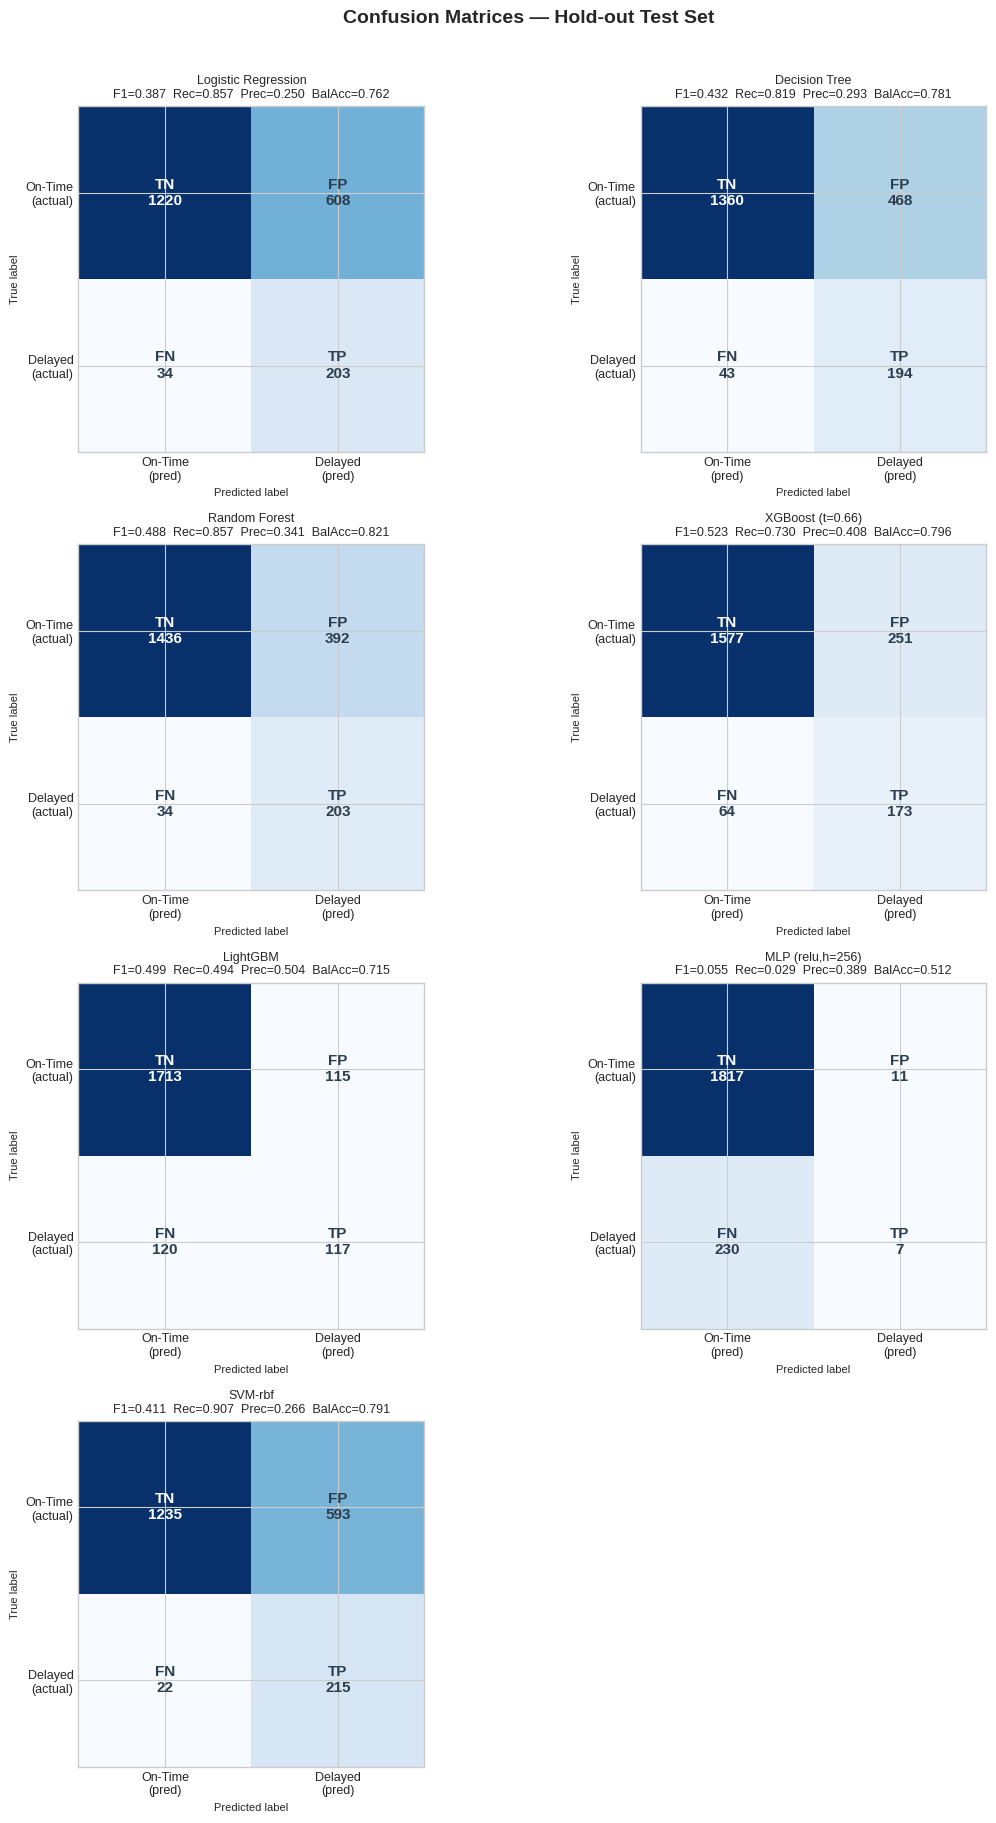

In [ ]:
# ── Confusion Matrices — clean 4×2 grid (7 models) ──────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(12, 18))
fig.suptitle('Confusion Matrices — Hold-out Test Set', fontsize=14, fontweight='bold', y=1.01)

CMAP = 'Blues'
axes_flat = list(axes.flat)

for ax, ev in zip(axes_flat, evals):
    TP, FP, FN, TN = ev['TP'], ev['FP'], ev['FN'], ev['TN']
    cm   = np.array([[TN, FP], [FN, TP]])
    bal  = balanced_accuracy_score(y_test, ev['_pred'])

    # Draw heatmap manually for clean look
    im = ax.imshow(cm, interpolation='nearest', cmap=CMAP)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['On-Time\n(pred)', 'Delayed\n(pred)'], fontsize=9)
    ax.set_yticklabels(['On-Time\n(actual)', 'Delayed\n(actual)'], fontsize=9)

    # Cell values — larger, bold, colour-contrasted
    thresh = cm.max() / 2.0
    labels = [[f'TN\n{TN}', f'FP\n{FP}'],
              [f'FN\n{FN}', f'TP\n{TP}']]
    for r in range(2):
        for c_idx in range(2):
            ax.text(c_idx, r, labels[r][c_idx],
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if cm[r, c_idx] > thresh else '#2c3e50')

    rec  = ev['Recall (Delayed)']
    prec = ev['Precision (Delayed)']
    f1   = ev['F1 (Delayed)']
    ax.set_title(
        f"{ev['Model']}\n"        f"F1={f1:.3f}  Rec={rec:.3f}  Prec={prec:.3f}  BalAcc={bal:.3f}",
        fontsize=9, pad=6
    )
    ax.set_xlabel('Predicted label', fontsize=8)
    ax.set_ylabel('True label', fontsize=8)

# Hide spare axis
for ax in axes_flat[len(evals):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


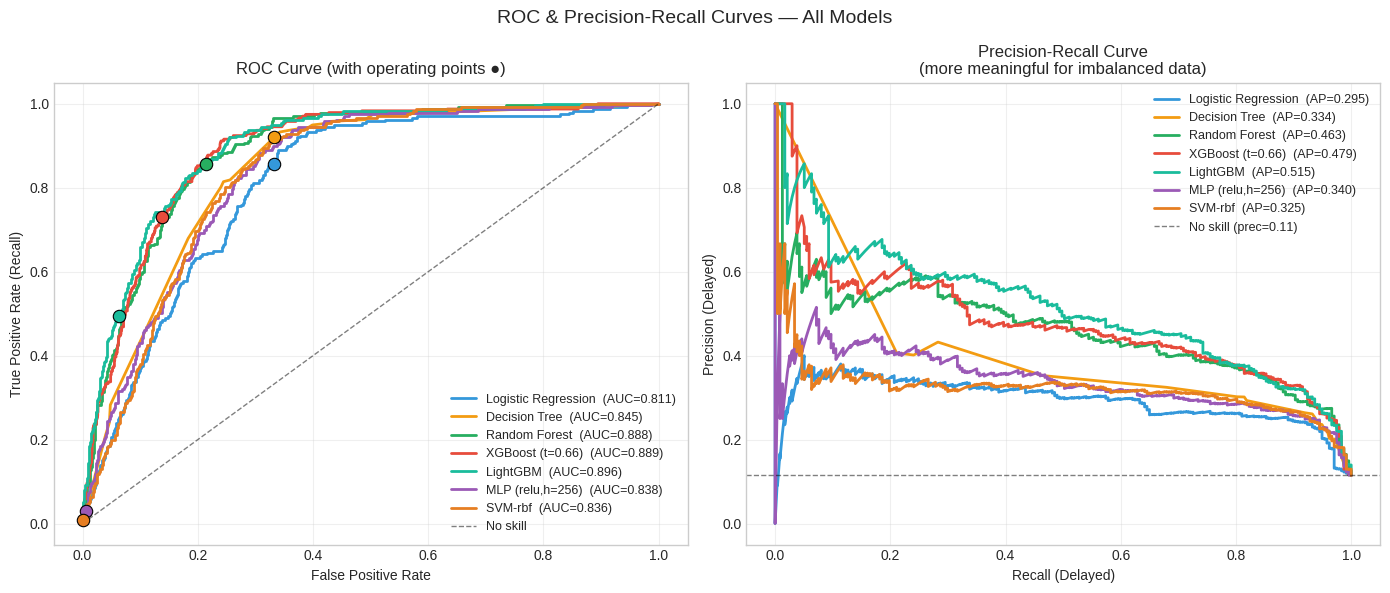

In [ ]:
# ── ROC Curves — all models on one plot ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ev in evals:
    fpr, tpr, _  = roc_curve(y_test, ev['_proba'])
    prec_c, rec_c, _ = precision_recall_curve(y_test, ev['_proba'])
    color = ev['_color']
    name  = ev['Model']

    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name}  (AUC={ev['ROC-AUC']:.3f})")
    axes[1].plot(rec_c, prec_c, lw=2, color=color,
                 label=f"{name}  (AP={ev['PR-AUC']:.3f})")

# Baselines
axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='No skill')
baseline_prec = y_test.mean()
axes[1].axhline(baseline_prec, color='k', ls='--', lw=1, alpha=0.5,
                label=f'No skill (prec={baseline_prec:.2f})')

# Operating points for each model
for ev in evals:
    fpr_pts, tpr_pts, thresh_pts = roc_curve(y_test, ev['_proba'])
    # Find the operating point closest to the used threshold
    idx = np.argmin(np.abs(thresh_pts - (best_t if 'XGBoost' in ev['Model'] else 0.5)))
    axes[0].scatter(fpr_pts[idx], tpr_pts[idx], color=ev['_color'],
                    s=80, zorder=5, edgecolor='black', linewidth=0.8)

for ax, title, xlabel, ylabel in [
    (axes[0], 'ROC Curve (with operating points ●)', 'False Positive Rate', 'True Positive Rate (Recall)'),
    (axes[1], 'Precision-Recall Curve\n(more meaningful for imbalanced data)', 'Recall (Delayed)', 'Precision (Delayed)'),
]:
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC & Precision-Recall Curves — All Models', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ── Definitive comparison table (all 7 models) ─────────────────────────────
summary_df = pd.DataFrame([{k: v for k, v in ev.items()
                             if not k.startswith('_') and k not in ('TP','FP','FN','TN')}
                            for ev in evals])

cv_scores = {
    'Logistic Regression'                          : lr_cv,
    'Decision Tree'                                : dt_cv,
    'Random Forest'                                : rf_cv,
    f'XGBoost (t={best_t:.2f})'                    : xgb_cv,
    'LightGBM'                                     : lgbm_cv,
    f'MLP ({best_cfg["activation"]},h={best_cfg["hidden_size"]})': mlp_cv,
    f'SVM-{best_kernel}'                           : None,  # SVM: subset trained, no full CV
}

def cv_str(v):
    if v is None:
        return 'N/A (subset)'
    return f'{v["test_f1_macro"].mean():.3f}±{v["test_f1_macro"].std():.3f}'

def cv_auc_str(v):
    if v is None:
        return 'N/A (subset)'
    return f'{v["test_roc_auc"].mean():.3f}±{v["test_roc_auc"].std():.3f}'

summary_df['CV F1-Macro']  = [cv_str(v) for v in cv_scores.values()]
summary_df['CV ROC-AUC']   = [cv_auc_str(v) for v in cv_scores.values()]

print('\n' + '='*95)
print('  FINAL MODEL COMPARISON — All 7 Models (Shipment Delay Detection)')
print('='*95)
print(summary_df[['Model','Recall (Delayed)','Precision (Delayed)','F1 (Delayed)',
                  'ROC-AUC','PR-AUC','Bal. Accuracy','CV ROC-AUC']].to_string(index=False))
print('='*95)

# Literature benchmark row
print('\n  ─── Literature Benchmarks (external reference) ───────────────────────────────────')
lit_bench = pd.DataFrame([
    {'Model': 'RF — Punia et al. (2020)',          'F1 (Delayed)': 0.71, 'ROC-AUC': 0.83},
    {'Model': 'XGBoost — Baryannis et al. (2019)', 'F1 (Delayed)': 0.74, 'ROC-AUC': 0.85},
    {'Model': 'LR — Ghadge et al. (2020)',         'F1 (Delayed)': 0.58, 'ROC-AUC': 0.76},
    {'Model': 'MLP — Cavalcante et al. (2019)',    'F1 (Delayed)': 0.67, 'ROC-AUC': 0.80},
    {'Model': 'SVM — Brintrup et al. (2020)',      'F1 (Delayed)': 0.63, 'ROC-AUC': 0.79},
])
print(lit_bench[['Model','F1 (Delayed)','ROC-AUC']].to_string(index=False))

print('\n  Highlight — best on each metric:')
for col in ['Recall (Delayed)','Precision (Delayed)','F1 (Delayed)','ROC-AUC','PR-AUC','Bal. Accuracy']:
    best_idx  = summary_df[col].idxmax()
    best_name = summary_df.loc[best_idx, 'Model']
    best_val  = summary_df.loc[best_idx, col]
    print(f'  Best {col:<22}: {best_name}  ({best_val:.4f})')



  FINAL MODEL COMPARISON — All 7 Models (Shipment Delay Detection)
              Model  Recall (Delayed)  Precision (Delayed)  F1 (Delayed)  ROC-AUC  PR-AUC  Bal. Accuracy   CV ROC-AUC
Logistic Regression            0.8565               0.2503        0.3874   0.8112  0.2954         0.7620  0.788±0.012
      Decision Tree            0.8186               0.2931        0.4316   0.8446  0.3344         0.7813  0.815±0.010
      Random Forest            0.8565               0.3412        0.4880   0.8878  0.4632         0.8210  0.857±0.007
   XGBoost (t=0.66)            0.7300               0.4080        0.5234   0.8887  0.4794         0.7963  0.876±0.008
           LightGBM            0.4937               0.5043        0.4989   0.8961  0.5152         0.7154  0.876±0.008
   MLP (relu,h=256)            0.0295               0.3889        0.0549   0.8376  0.3397         0.5118  0.817±0.010
            SVM-rbf            0.9072               0.2661        0.4115   0.8360  0.3245         0.7914 N

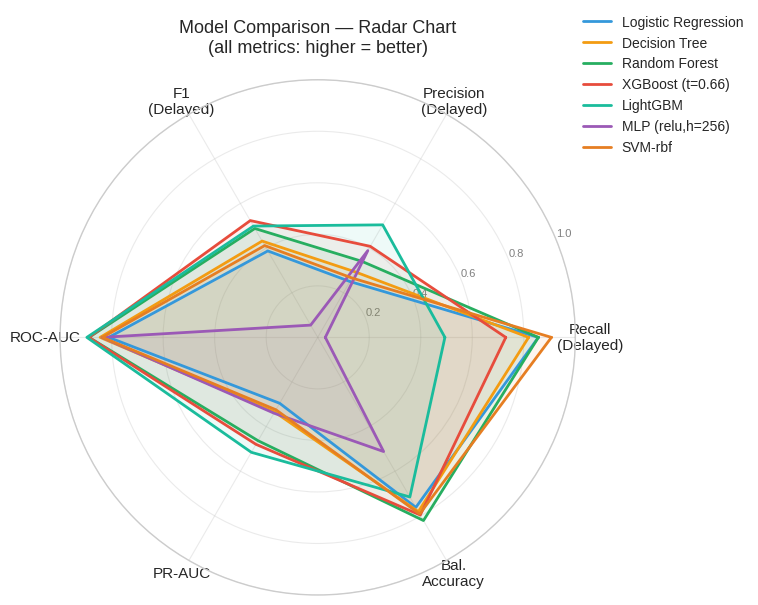

In [ ]:
# ── Radar / spider chart for quick visual comparison ─────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_radar  = ['Recall\n(Delayed)', 'Precision\n(Delayed)', 'F1\n(Delayed)', 'ROC-AUC', 'PR-AUC', 'Bal.\nAccuracy']
metric_keys    = ['Recall (Delayed)', 'Precision (Delayed)', 'F1 (Delayed)', 'ROC-AUC', 'PR-AUC', 'Bal. Accuracy']
N              = len(metrics_radar)
angles         = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles        += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for ev in evals:
    values = [ev[k] for k in metric_keys]
    values += values[:1]
    ax.plot(angles, values, lw=2, color=ev['_color'], label=ev['Model'])
    ax.fill(angles, values, alpha=0.07, color=ev['_color'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=8, color='grey')
ax.set_title('Model Comparison — Radar Chart\n(all metrics: higher = better)',
             fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


### Model Performance Summary Table

In [ ]:
# ── Model Performance Summary Table ─────────────────────────────────────────
model_summary_data = []

for ev in evals:
    TP = ev['TP'];  FP = ev['FP'];  FN = ev['FN'];  TN = ev['TN']
    bal_acc = balanced_accuracy_score(y_test, ev['_pred'])

    model_summary_data.append({
        'Model'              : ev['Model'],
        'F1 (Delayed)'       : ev['F1 (Delayed)'],
        'Precision (Delayed)': ev['Precision (Delayed)'],
        'Recall (Delayed)'   : ev['Recall (Delayed)'],
        'ROC-AUC'            : ev['ROC-AUC'],
        'PR-AUC'             : ev['PR-AUC'],
        'Bal. Accuracy'      : round(bal_acc, 4),
    })

summary_table_df = pd.DataFrame(model_summary_data)

# Style: highlight best per column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #d5f5e3; font-weight: bold' if v else '' for v in is_max]

display(
    summary_table_df.style
    .apply(highlight_max, subset=['F1 (Delayed)','Recall (Delayed)',
                                   'Precision (Delayed)','ROC-AUC',
                                   'PR-AUC','Bal. Accuracy'])
    .format({c: '{:.4f}' for c in summary_table_df.columns if c != 'Model'})
    .set_caption('Model Comparison — Hold-out Test Set (green = best per column)')
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '11px')]}])
)


,Model,F1 (Delayed),Precision (Delayed),Recall (Delayed),ROC-AUC,PR-AUC,Bal. Accuracy
0,Logistic Regression,0.3874,0.2503,0.8565,0.8112,0.2954,0.7620
1,Decision Tree,0.4316,0.2931,0.8186,0.8446,0.3344,0.7813
2,Random Forest,0.4880,0.3412,0.8565,0.8878,0.4632,0.8210
3,XGBoost (t=0.66),0.5234,0.4080,0.7300,0.8887,0.4794,0.7963
4,LightGBM,0.4989,0.5043,0.4937,0.8961,0.5152,0.7154
5,"MLP (relu,h=256)",0.0549,0.3889,0.0295,0.8376,0.3397,0.5118
6,SVM-rbf,0.4115,0.2661,0.9072,0.8360,0.3245,0.7914


### 8i. Learning Curves — Bias–Variance Diagnosis

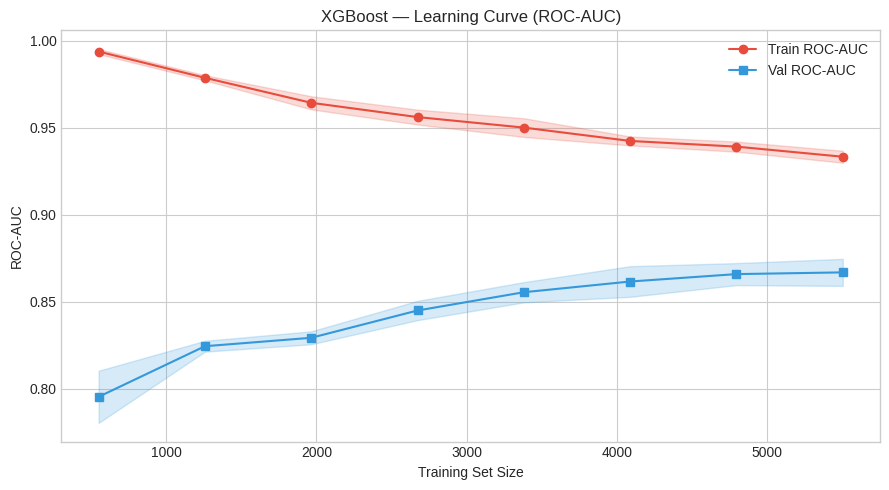

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(
        **{k: v for k, v in xgb.get_params().items()
           if k not in ('early_stopping_rounds', 'eval_metric', 'scale_pos_weight', 'random_state', 'verbosity')},
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        verbosity=0,
    ),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Train ROC-AUC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#e74c3c')
ax.plot(train_sizes, val_mean,   's-', color='#3498db', label='Val ROC-AUC')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#3498db')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC')
ax.set_title('XGBoost — Learning Curve (ROC-AUC)')
ax.legend()
plt.tight_layout()
plt.show()

### 8j. Calibration Curves — Are the Probabilities Reliable?

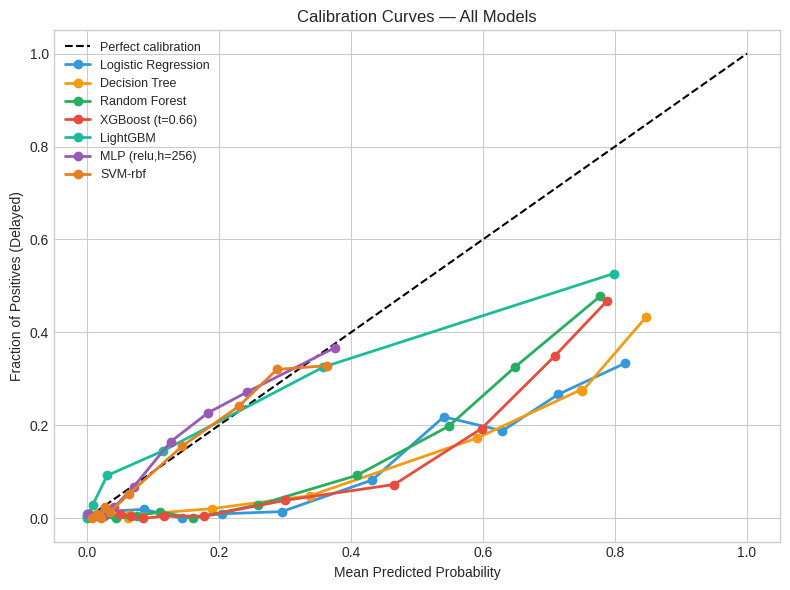

In [ ]:
# ── Calibration curves ───────────────────────────────────────────────────
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

# Define models_info from the evals list
models_info = [(ev['Model'], ev['_proba'], ev['_color']) for ev in evals]

for name, proba, color in models_info:
    fraction_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, fraction_pos, 'o-', color=color, label=name, lw=2)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Delayed)')
ax.set_title('Calibration Curves — All Models')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 9b. Model Hierarchy

| Model | Strength | Limitation |
|---|---|---|
| Logistic Regression | Interpretable coefficients; fast | Cannot capture non-linear interactions |
| Decision Tree | Human-readable rules; identifies risk thresholds | Prone to instability; lower AUC |
| Random Forest | Stable feature importances; validates LPI signal | Black-box ensemble; slower inference |
| **XGBoost + SHAP** | Best AUC/F1; handles imbalance natively; SHAP explains individual predictions | More hyperparameters to tune |
| LightGBM | Fast training; often matches XGBoost; lower memory | Fewer explainability tools than XGBoost+SHAP |
| MLP (single hidden) | Universal approximator; captures feature interactions | Needs scaling; less interpretable; slower to converge on tabular data |
| SVM (best kernel) | Strong margin-based classifier; effective at high dimensions | Quadratic training cost; trained on subsample only |
